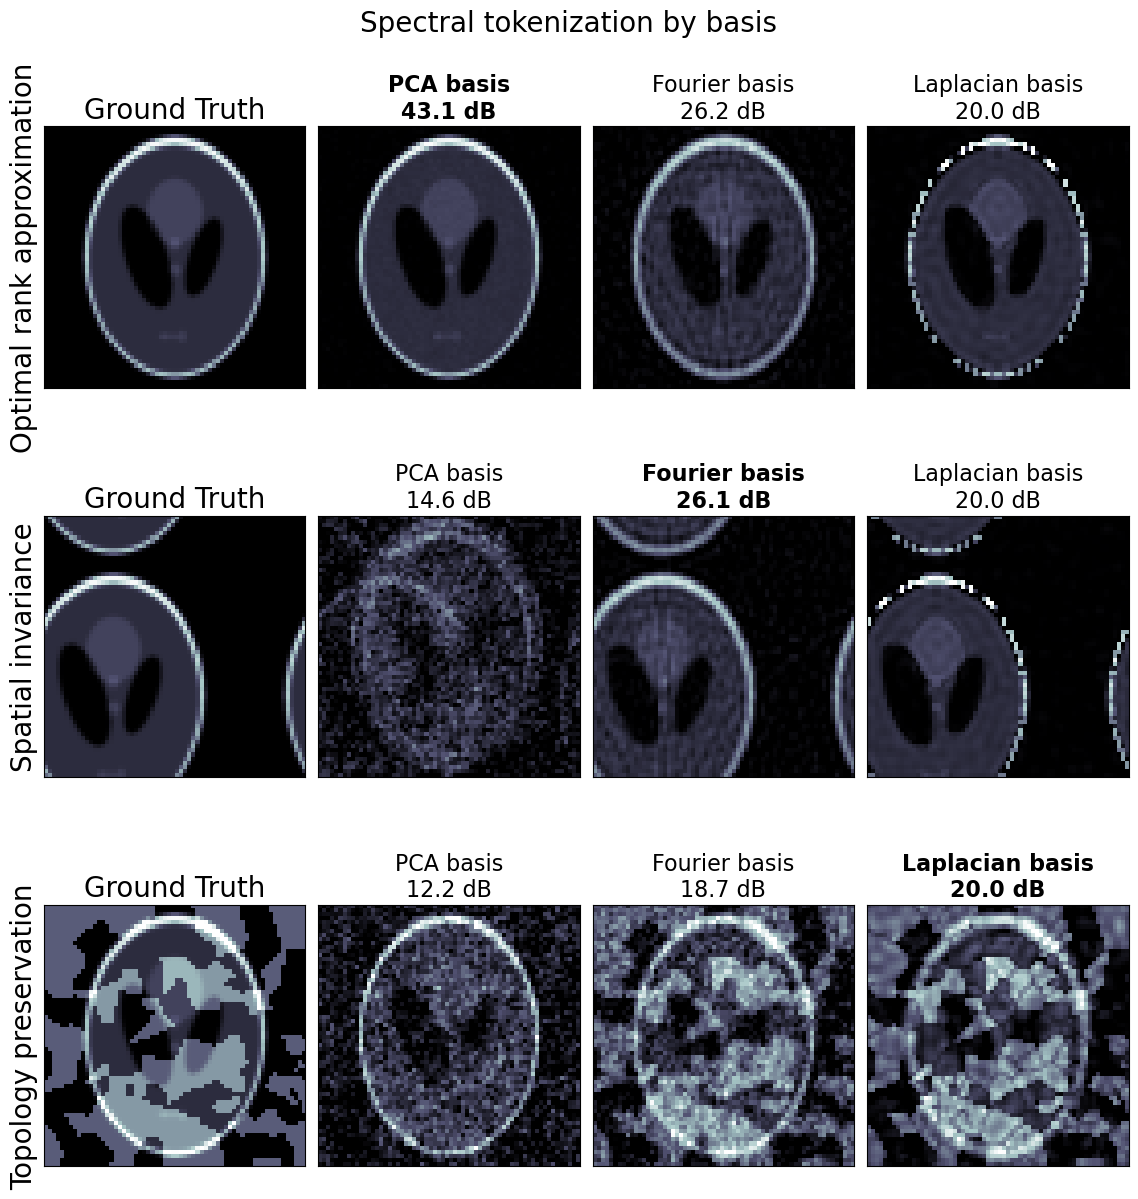

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.fftpack import fft2, ifft2, fftshift, ifftshift
from scipy.sparse.linalg import eigsh
from scipy.sparse import csr_matrix, eye
from skimage.data import shepp_logan_phantom
from skimage.transform import resize
from scipy.ndimage import gaussian_filter
from scipy.spatial import KDTree

# Setup
img_size = 64
K = 1024 
noise_lvl = 0.02 
np.random.seed(0)

# Base phantom
phantom_base = shepp_logan_phantom()
phantom_base = resize(phantom_base, (img_size, img_size))

# =============================================================================
# Processing Functions
# =============================================================================

def pca_tokenize(X_train, img_test, k):
    n_comp = min(k, X_train.shape[0])
    pca = PCA(n_components=n_comp).fit(X_train)
    tokens = pca.transform(img_test.flatten().reshape(1, -1))
    img_recon = pca.inverse_transform(tokens).reshape(img_size, img_size)
    return tokens.flatten(), img_recon

def fourier_tokenize(img, k):
    kspace = fftshift(fft2(img))
    kspace_flat = kspace.flatten()
    idx = np.argsort(np.abs(kspace_flat))[::-1]
    kspace_recon = np.zeros_like(kspace_flat, dtype=complex)
    kspace_recon[idx[:k]] = kspace_flat[idx[:k]]
    img_recon = np.real(ifft2(ifftshift(kspace_recon.reshape(img_size, img_size))))
    # Magnitude tokens provide translation invariance
    return np.abs(kspace_flat[idx[:k]]), img_recon

def laplacian_tokenize(img_clean, img_noisy, k, threshold=0.03, topo_labels=None):
    n_pixels = img_size * img_size
    img_flat = img_clean.flatten()
    rows, cols, vals = [], [], []
    
    for i in range(n_pixels):
        r, c = divmod(i, img_size)
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nr, nc = r + dr, c + dc
            if 0 <= nr < img_size and 0 <= nc < img_size:
                j = nr * img_size + nc
                if topo_labels is not None:
                    weight = 1.0 if topo_labels.flat[i] == topo_labels.flat[j] else 0.0001
                else:
                    weight = np.exp(-np.abs(img_flat[i] - img_flat[j])**2 / (2 * threshold**2))
                rows.append(i); cols.append(j); vals.append(weight)
    
    W = csr_matrix((vals, (rows, cols)), shape=(n_pixels, n_pixels))
    d = np.array(W.sum(axis=1)).flatten()
    D_inv_sqrt = csr_matrix((np.power(d, -0.5, where=d!=0), (range(n_pixels), range(n_pixels))))
    L = eye(n_pixels) - D_inv_sqrt @ W @ D_inv_sqrt
    _, evecs = eigsh(L, k=k, which='SM')
    tokens = evecs.T @ img_noisy.flatten()
    img_recon = (evecs @ tokens).reshape(img_size, img_size)
    return tokens, img_recon

def psnr(gt, recon):
    mse = np.mean((gt - recon)**2)
    return 20 * np.log10(1.0 / np.sqrt(mse)) if mse > 0 else 100

# =============================================================================
# SCENARIOS
# =============================================================================

# Row 1: Optimal rank approximation (PCA Win)
X_train_pca = np.array([(np.roll(phantom_base, np.random.randint(-2, 2, 2), axis=(0, 1)) + 
                         gaussian_filter(np.random.randn(img_size, img_size)*0.01, 0.5)).flatten() for _ in range(512)])
phantom_pca = phantom_base.copy()

# Row 2: Translation Invariance (Fourier Win)
# We shift the phantom significantly. Fourier (Magnitude) remains invariant.
phantom_fourier = np.roll(phantom_base, shift=(12, -15), axis=(0, 1))

# Row 3: Topology preservation (Laplacian Win)
points = np.random.rand(150, 2) * img_size
tree = KDTree(points)
y_grid, x_grid = np.mgrid[:img_size, :img_size]
voronoi_labels = tree.query(np.c_[y_grid.ravel(), x_grid.ravel()])[1].reshape(img_size, img_size)
cellular = (voronoi_labels % 2 == 0).astype(float) * 0.4
phantom_laplacian = np.clip(phantom_base + cellular, 0, 1)

scenarios = [
    (phantom_pca, "Optimal rank approximation", None),
    (phantom_fourier, "Spatial invariance", None),
    (phantom_laplacian, "Topology preservation", voronoi_labels)
]

# =============================================================================
# VISUALIZATION
# =============================================================================
fig, axes = plt.subplots(3, 4, figsize=(14, 14))
plt.subplots_adjust(wspace=0.05, hspace=0.3) 

for i, (gt, row_name, labels) in enumerate(scenarios):
    effective_noise = 0.12 if i == 2 else noise_lvl
    noisy = gt + np.random.normal(0, effective_noise, gt.shape)
    
    _, r_pca = pca_tokenize(X_train_pca, noisy, K)
    _, r_fou = fourier_tokenize(noisy, K)
    _, r_lap = laplacian_tokenize(gt, noisy, K, topo_labels=labels) 
    
    recons = [r_pca, r_fou, r_lap]
    titles = ["PCA basis", "Fourier basis", "Laplacian basis"]
    psnrs = [psnr(gt, r) for r in recons]
    
    axes[i, 0].imshow(gt, cmap='bone', vmin=0, vmax=1)
    axes[i, 0].set_title("Ground Truth", fontsize=20)
    axes[i, 0].set_ylabel(row_name,fontsize=20)

    for j, r in enumerate(recons):
        is_winner = psnrs[j] == max(psnrs)
        axes[i, j+1].imshow(r, cmap='bone', vmin=0, vmax=1)
        axes[i, j+1].set_title(f"{titles[j]}\n{psnrs[j]:.1f} dB", 
                               fontsize=16, fontweight='bold' if is_winner else 'normal',
                               )

for ax in axes.flatten():
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle(f'Spectral tokenization by basis', fontsize=20, y=0.95)
plt.show()